# Simple Image Filters with OpenCV

This notebook introduces **custom convolution filters** using OpenCV's `filter2D` function. We focus on a **sharpening filter** built from scratch as a NumPy kernel, then applied to a real image.

**What we'll learn:**
- How to load and display images with OpenCV and Matplotlib
- What a convolution kernel is and how it works
- How to construct a sharpening kernel manually
- How to apply any custom kernel with `cv2.filter2D`

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import requests

## 1. Loading the Image

We fetch a sample grayscale JPEG from the web, save it locally, then reload it with OpenCV.

> **Note:** OpenCV loads images in BGR order by default. Since this image is already grayscale, we convert it explicitly with `cv2.cvtColor` to ensure a single-channel representation compatible with Matplotlib's `'gray'` colormap.

In [ ]:
image_url = "https://media.geeksforgeeks.org/wp-content/uploads/gray.jpeg"

img_data = requests.get(image_url).content
with open('image.jpg', 'wb') as f:
    f.write(img_data)

In [5]:
# reand and converts the image to Gray Scale, cv defaults load into RGB
image = cv2.imread('image.jpg')
gray_image = cv2.cvtColor(image, cv2.IMREAD_GRAYSCALE)

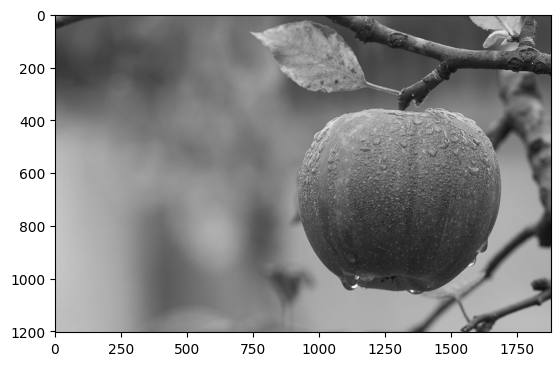

In [6]:
plt.imshow(gray_image, cmap="gray")

## 2. Sharpening Filter

A **convolution filter** slides a small matrix (the *kernel*) across every pixel of the image, computing a weighted sum of the neighbourhood to produce the output value.

A sharpening kernel works by **amplifying the center pixel** and **subtracting the surrounding neighbours**. For a `k×k` kernel this looks like:

```
-1  -1  -1  -1  -1
-1  -1  -1  -1  -1
-1  -1  24  -1  -1     ← center = k²,  all others = -1
-1  -1  -1  -1  -1
-1  -1  -1  -1  -1
```

The weights sum to **0** (k² − (k²−1) = 1), so uniform regions are unchanged while edges — where pixel values differ — are enhanced.

### `sharpen_filter(k)` — kernel construction

| Step | What happens |
|------|-------------|
| Fill `k×k` matrix with `-1` | Penalise every neighbour |
| Set `kernel[center, center] = k²` | Boost the center pixel strongly enough to keep the overall sum = 1 |
| Validate `k` is odd and ≥ 3 | Even-sized kernels have no single center pixel |

In [7]:
def sharpen_filter(k):
    if k %2 == 0 or k < 3:
        raise ValueError("The kernell dimension (k) must be an odd number >= 3.")
    
    kernel = np.ones((k, k))*-1

    center = k // 2

    kernel[center, center]= k * k

    return kernel

In [18]:
k = 5
kernel = sharpen_filter(k)

sharpen_image = cv2.filter2D(
    image, -1, kernel
)

### Applying the filter with `cv2.filter2D`

`cv2.filter2D(src, ddepth, kernel)` performs the 2D convolution:
- **`src`** — input image (BGR or grayscale)
- **`ddepth = -1`** — output depth same as input (e.g. `uint8`)
- **`kernel`** — our custom NumPy array

OpenCV handles border pixels automatically (default: `BORDER_REFLECT`).

> **Tip:** Try different values of `k` (3, 5, 7, …) to see how kernel size controls sharpening strength. Larger kernels incorporate more neighbours and produce a more aggressive effect.

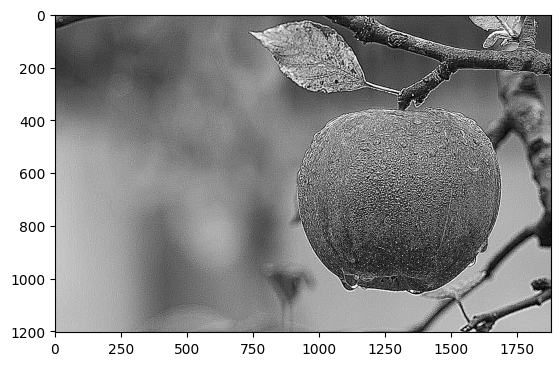

In [19]:
plt.imshow(sharpen_image, cmap='gray')

## Summary

| Concept | Key takeaway |
|---------|-------------|
| Convolution kernel | A small weight matrix slid across the image to transform each pixel |
| Sharpening kernel | Center weight = k², all neighbours = −1; edges become more pronounced |
| `cv2.filter2D` | OpenCV's generic 2D convolution — works with any custom kernel |
| Kernel size `k` | Must be odd; larger k → wider neighbourhood → stronger effect |